# 🧠 CT/MRI Registration Pipeline — VTU Mesh Version
> **SimpleITK + PyVista | No ANTs | `.vtu` input & output throughout**

| Cell | Stage | Description | Est. Time |
|------|-------|-------------|-----------|
| 1 | Install | Dependencies | once/session |
| 2 | Config | Set file paths | < 5 sec |
| 3 | VTU Reader | Load `.vtu` → extract points → voxelize | < 30 sec |
| 4 | Helpers | Load functions | < 5 sec |
| 5 | Preprocess | Resample → Normalize → Center align | < 30 sec |
| 6 | Rigid | 6-DOF registration | ~1 min |
| 7 | Affine | 12-DOF refinement | ~1 min |
| 8 | Deformable | Demons non-linear warp | ~1 min |
| 9 | Apply to Mesh | Warp VTU node coordinates → new `.vtu` | < 30 sec |
| 10 | Validation | Visual + Dice + displacement histogram | < 30 sec |

**Total: ~4-5 minutes**

### How `.vtu` files are handled
- **Input CT** : `.nii.gz` voxel volume (fixed image)
- **Input Mesh** : `.vtu` UnstructuredGrid (converted from `.k` or `.stl`)
  - Node coordinates extracted and voxelized for registration
  - Final composite transform applied back to every mesh point
  - New `*_registered.vtu` written — all cell/point data preserved


## Cell 1 — Install

In [2]:
!pip install SimpleITK nibabel matplotlib numpy pyvista vtk -q

import SimpleITK as sitk
import pyvista as pv
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import os, time

print(f'SimpleITK : {sitk.Version.VersionString()}')
print(f'pyvista   : {pv.__version__}')
print(f'numpy     : {np.__version__}')


SimpleITK : 2.5.5
pyvista   : 0.48.4
numpy     : 2.2.5


## Cell 2 — Config

In [4]:
# USER EDIT
# USER EDIT
CT_PATH    = r'/run/media/asusry7/Extreme SSD/2d_3d_regis dataset/New_version/Data/head-Model-label.nii.gz'
MESH_PATH  = r'/run/media/asusry7/Extreme SSD/2d_3d_regis dataset/New_version/Data/outputs/vtk_export/Head_V6.vtu'
#                                                                                                         ↑ the actual file, not the folder
OUTPUT_DIR = '/run/media/asusry7/Extreme SSD/2d_3d_regis dataset/New_version/Data/outputs/case01'
VOXEL_SIZE_MM = 1.0

os.makedirs(OUTPUT_DIR, exist_ok=True)
stem = os.path.splitext(os.path.basename(MESH_PATH))[0]

print(f'Output : {OUTPUT_DIR}')
print(f'CT     : {CT_PATH}   exists={os.path.exists(CT_PATH)}')
print(f'Mesh   : {MESH_PATH}  exists={os.path.exists(MESH_PATH)}')


Output : /run/media/asusry7/Extreme SSD/2d_3d_regis dataset/New_version/Data/outputs/case01
CT     : /run/media/asusry7/Extreme SSD/2d_3d_regis dataset/New_version/Data/head-Model-label.nii.gz   exists=True
Mesh   : /run/media/asusry7/Extreme SSD/2d_3d_regis dataset/New_version/Data/outputs/vtk_export/Head_V6.vtu  exists=True


In [5]:
import os, pyvista as pv

print("File exists :", os.path.exists(MESH_PATH))
print("Is file     :", os.path.isfile(MESH_PATH))
print("Is dir      :", os.path.isdir(MESH_PATH))

# List what .vtu files are actually in the export folder
export_folder = r'/run/media/asusry7/Extreme SSD/2d_3d_regis dataset/New_version/Data/outputs/vtk_export'
print("\n.vtu files found:")
for f in os.listdir(export_folder):
    if f.endswith('.vtu'):
        print(f"  {f}")

File exists : True
Is file     : True
Is dir      : False

.vtu files found:
  ImageToStl.com_head_voxels.vtu
  Head_V6.vtu


## Cell 3 — VTU Reader & Voxelizer

In [6]:
# Load VTU
print('Loading VTU mesh...')
vtu_mesh = pv.read(MESH_PATH)
nodes_original = np.array(vtu_mesh.points, dtype=np.float64)
n_nodes = len(nodes_original)

print(f'  Points   : {n_nodes:,}')
print(f'  Bounds X : [{nodes_original[:,0].min():.4f}, {nodes_original[:,0].max():.4f}]')
print(f'  Bounds Y : [{nodes_original[:,1].min():.4f}, {nodes_original[:,1].max():.4f}]')
print(f'  Bounds Z : [{nodes_original[:,2].min():.4f}, {nodes_original[:,2].max():.4f}]')

# ── Auto-scale: match mesh bounding box to CT bounding box ───────────────────
# If CT is in mm (~150-250mm range) but mesh is in m (~0.15-0.25m),
# registration will never converge. Detect and rescale automatically.

def auto_rescale_to_ct(nodes, ct_path):
    """
    If the mesh bounding box is >10x smaller or larger than a typical
    head CT (150-250mm), rescale the nodes to match CT physical space.
    Returns rescaled nodes and the scale factor applied.
    """
    ct_img  = sitk.ReadImage(ct_path, sitk.sitkFloat32)
    ct_size = ct_img.GetSize()
    ct_sp   = ct_img.GetSpacing()
    ct_phys = [ct_size[i] * ct_sp[i] for i in range(3)]  # physical extent mm

    mesh_extent = nodes.max(axis=0) - nodes.min(axis=0)

    # Ratio of CT extent to mesh extent in each axis
    ratios = np.array(ct_phys) / (mesh_extent + 1e-8)
    median_ratio = np.median(ratios)

    print(f'\n  CT physical extent  : {[f"{v:.1f}" for v in ct_phys]} mm')
    print(f'  Mesh extent         : {[f"{v:.4f}" for v in mesh_extent]}')
    print(f'  Scale ratio (CT/mesh): {median_ratio:.4f}')

    if 0.8 < median_ratio < 1.2:
        print('  Scale match OK — no rescaling needed')
        return nodes, 1.0

    print(f'  Rescaling mesh by {median_ratio:.4f} to match CT space...')
    centroid = nodes.mean(axis=0)
    nodes_scaled = (nodes - centroid) * median_ratio + centroid
    return nodes_scaled, median_ratio


nodes_working, scale_factor = auto_rescale_to_ct(nodes_original, CT_PATH)

print(f'\n  Working bounds X : [{nodes_working[:,0].min():.2f}, {nodes_working[:,0].max():.2f}]')
print(f'  Working bounds Y : [{nodes_working[:,1].min():.2f}, {nodes_working[:,1].max():.2f}]')
print(f'  Working bounds Z : [{nodes_working[:,2].min():.2f}, {nodes_working[:,2].max():.2f}]')

# Voxelize
def voxelize_nodes(nodes, voxel_size=1.0, margin_mm=10.0):
    mins = nodes.min(axis=0) - margin_mm
    maxs = nodes.max(axis=0) + margin_mm
    dims = np.ceil((maxs - mins) / voxel_size).astype(int)
    volume  = np.zeros(dims[::-1], dtype=np.float32)
    indices = np.clip(
        np.floor((nodes - mins) / voxel_size).astype(int), 0, dims - 1
    )
    volume[indices[:,2], indices[:,1], indices[:,0]] = 1.0
    img = sitk.GetImageFromArray(volume)
    img.SetSpacing([voxel_size]*3)
    img.SetOrigin(mins.tolist())
    return img

print(f'\nVoxelizing at {VOXEL_SIZE_MM} mm...')
moving_raw = voxelize_nodes(nodes_working, voxel_size=VOXEL_SIZE_MM)

# Apply Gaussian blur to soften the binary volume
# This gives MI and MeanSquares a smooth gradient to follow
# instead of a hard binary edge — critical for convergence
moving_raw = sitk.SmoothingRecursiveGaussian(moving_raw, sigma=2.0)

print(f'  Volume size : {moving_raw.GetSize()}')
sitk.WriteImage(moving_raw, os.path.join(OUTPUT_DIR, 'mesh_voxelized.nii.gz'))
print('  Saved -> mesh_voxelized.nii.gz')

Loading VTU mesh...
  Points   : 179,676
  Bounds X : [-283.3564, -52.3074]
  Bounds Y : [-82.5947, 82.5947]
  Bounds Z : [519.1418, 770.8899]

  CT physical extent  : ['595.1', '479.5', '389.0'] mm
  Mesh extent         : ['231.0490', '165.1895', '251.7481']
  Scale ratio (CT/mesh): 2.5756
  Rescaling mesh by 2.5756 to match CT space...

  Working bounds X : [-438.32, 156.78]
  Working bounds Y : [-212.73, 212.73]
  Working bounds Z : [273.08, 921.49]

Voxelizing at 1.0 mm...
  Volume size : (616, 446, 669)
  Saved -> mesh_voxelized.nii.gz


## Cell 4 — Helper Functions

In [7]:
def fix_spacing(img, default=1.0):
    sp = list(img.GetSpacing())
    fixed = [s if s > 0.001 else default for s in sp]
    if fixed != sp:
        print(f'  Corrected spacing {sp} -> {fixed}')
        img.SetSpacing(fixed)
    return img


def resample_isotropic(image, voxel_size=1.0, interpolator=sitk.sitkLinear):
    orig_sp   = image.GetSpacing()
    orig_size = image.GetSize()
    new_size  = [int(round(orig_size[i] * orig_sp[i] / voxel_size)) for i in range(3)]
    return sitk.Resample(
        image, new_size, sitk.Transform(), interpolator,
        image.GetOrigin(), [voxel_size]*3, image.GetDirection(),
        0.0, image.GetPixelID()
    )


def normalize_intensity(image):
    arr = sitk.GetArrayFromImage(image).astype(np.float32)
    vmin, vmax = arr.min(), arr.max()
    if vmax - vmin < 1e-6:
        return image
    out = sitk.GetImageFromArray((arr - vmin) / (vmax - vmin))
    out.CopyInformation(image)
    return out


def print_image_info(name, img):
    arr = sitk.GetArrayFromImage(img)
    nz  = int(np.count_nonzero(arr))
    print(f'{name}:')
    print(f'  Size    : {img.GetSize()}')
    print(f'  Spacing : {[round(s,3) for s in img.GetSpacing()]}')
    print(f'  Origin  : {[round(o,2) for o in img.GetOrigin()]}')
    print(f'  Min/Max : {arr.min():.4f} / {arr.max():.4f}')
    print(f'  Nonzero : {nz:,} / {arr.size:,} ({100*nz/arr.size:.1f}%)')


def show_overlay(fixed, moving_reg, title='Registration Result', slices=None):
    def norm(a):
        a = a.astype(np.float32)
        mn, mx = a.min(), a.max()
        return (a - mn) / (mx - mn + 1e-8)
    f_arr = norm(sitk.GetArrayFromImage(fixed))
    m_arr = norm(sitk.GetArrayFromImage(moving_reg))
    z, y, x = [d//2 for d in f_arr.shape]
    if slices:
        z, y, x = slices
    views = [
        (f_arr[z,:,:], m_arr[z,:,:], 'Axial'),
        (f_arr[:,y,:], m_arr[:,y,:], 'Coronal'),
        (f_arr[:,:,x], m_arr[:,:,x], 'Sagittal'),
    ]
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    fig.suptitle(title, fontsize=13, fontweight='bold')
    for ax, (ct_sl, m_sl, label) in zip(axes, views):
        rgb = np.zeros((*ct_sl.shape, 3), dtype=np.float32)
        rgb[...,0] = ct_sl
        rgb[...,1] = m_sl
        ax.imshow(rgb, origin='lower')
        ax.set_title(f'{label}  |  Red=CT  Green=Mesh  Yellow=Overlap')
        ax.axis('off')
    plt.tight_layout()
    out = os.path.join(OUTPUT_DIR, f"{title.replace(' ','_')}.png")
    plt.savefig(out, dpi=120)
    plt.show()
    print(f'  Saved -> {out}')


metric_log = []
def log_metric(method):
    v = method.GetMetricValue()
    i = method.GetOptimizerIteration()
    metric_log.append((i, v))
    if i % 20 == 0:
        print(f'  Iter {i:04d}  |  Metric: {v:.6f}')


def plot_convergence(title='Convergence', color='steelblue'):
    if not metric_log:
        return
    iters, vals = zip(*metric_log)
    plt.figure(figsize=(8, 3))
    plt.plot(iters, vals, color=color)
    plt.xlabel('Iteration')
    plt.ylabel('MI Metric')
    plt.title(f'{title} (more negative = better)')
    plt.tight_layout()
    plt.show()


def checkerboard(a, b, block=20):
    out = np.zeros_like(a)
    for i in range(0, a.shape[0], block):
        for j in range(0, a.shape[1], block):
            src = a if ((i//block)+(j//block))%2==0 else b
            out[i:i+block, j:j+block] = src[i:i+block, j:j+block]
    return out


print('Helper functions loaded.')


Helper functions loaded.


## Cell 5 — Preprocess: Load -> Resample -> Normalize -> Center Align

Loading CT (fixed)...
CT  (raw):
  Size    : (309, 249, 202)
  Spacing : [1.926, 1.926, 1.926]
  Origin  : [256.0, 4.12, 38.3]
  Min/Max : 0.0000 / 1.0000
  Nonzero : 7,313,333 / 15,542,082 (47.1%)

VTU mesh voxelized (raw):
  Size    : (616, 446, 669)
  Spacing : [1.0, 1.0, 1.0]
  Origin  : [-448.32, -222.73, 263.08]
  Min/Max : -0.0001 / 0.0991
  Nonzero : 158,693,406 / 183,798,384 (86.3%)

Resampling to 1.0 mm isotropic...
  CT   -> (595, 480, 389)
  Mesh -> (616, 446, 669)

Normalizing intensity to [0, 1]...

Center alignment...


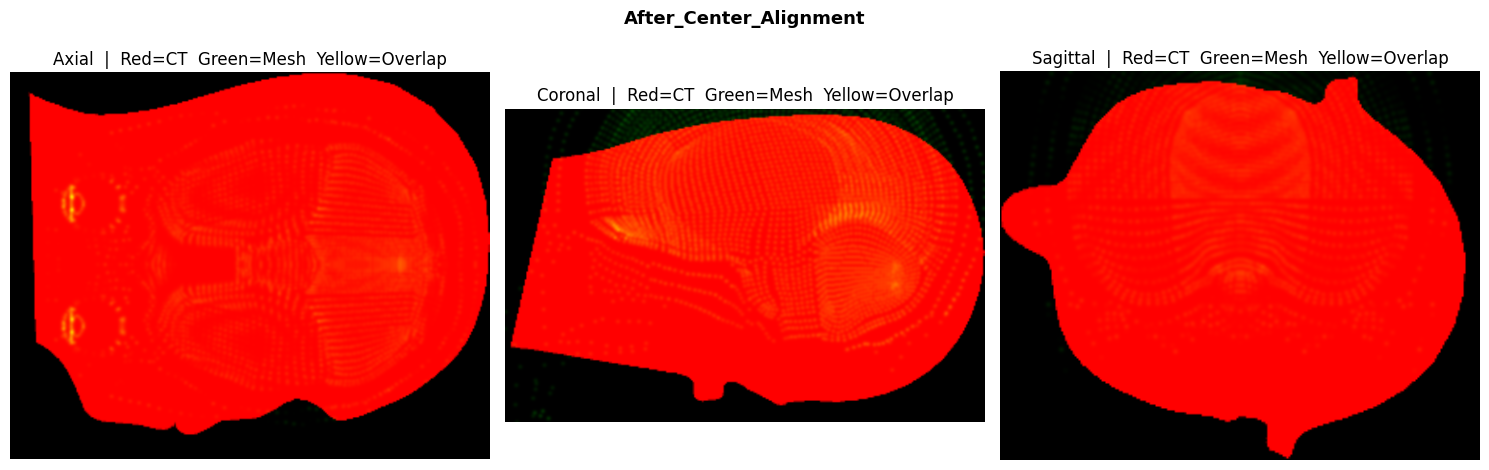

  Saved -> /run/media/asusry7/Extreme SSD/2d_3d_regis dataset/New_version/Data/outputs/case01/After_Center_Alignment.png
Preprocessing complete.


In [8]:
print('Loading CT (fixed)...')
fixed_raw = sitk.ReadImage(CT_PATH, sitk.sitkFloat32)
print_image_info('CT  (raw)', fixed_raw)
print()
print_image_info('VTU mesh voxelized (raw)', moving_raw)

fixed_raw  = fix_spacing(fixed_raw)
moving_raw = fix_spacing(moving_raw)

print('\nResampling to 1.0 mm isotropic...')
fixed  = resample_isotropic(fixed_raw,  voxel_size=1.0)
moving = resample_isotropic(moving_raw, voxel_size=1.0)
print(f'  CT   -> {fixed.GetSize()}')
print(f'  Mesh -> {moving.GetSize()}')

print('\nNormalizing intensity to [0, 1]...')
fixed  = normalize_intensity(fixed)
moving = normalize_intensity(moving)

sitk.WriteImage(fixed,  os.path.join(OUTPUT_DIR, 'ct_preprocessed.nii.gz'))
sitk.WriteImage(moving, os.path.join(OUTPUT_DIR, 'mesh_preprocessed.nii.gz'))

print('\nCenter alignment...')
initial_tx = sitk.CenteredTransformInitializer(
    fixed, moving,
    sitk.Euler3DTransform(),
    sitk.CenteredTransformInitializerFilter.GEOMETRY
)

resampler = sitk.ResampleImageFilter()
resampler.SetReferenceImage(fixed)
resampler.SetInterpolator(sitk.sitkLinear)
resampler.SetDefaultPixelValue(0)
resampler.SetTransform(initial_tx)
moving_init = resampler.Execute(moving)
sitk.WriteImage(moving_init, os.path.join(OUTPUT_DIR, 'mesh_center_aligned.nii.gz'))

show_overlay(fixed, moving_init, title='After_Center_Alignment')
print('Preprocessing complete.')


## Cell 6 — Rigid Registration (6-DOF)

Rigid Registration (MeanSquares + large LR)...
  Iter 0000  |  Metric: 0.467294
  Iter 0020  |  Metric: 0.463829
  Iter 0000  |  Metric: 0.469983
  Iter 0000  |  Metric: 0.479034
  Iter 0000  |  Metric: 0.491094
  Iter 0020  |  Metric: 0.484709
  Iter 0040  |  Metric: 0.484354

  Metric : 0.484418
  Stop   : GradientDescentOptimizerv4Template: Convergence checker passed at iteration 44.


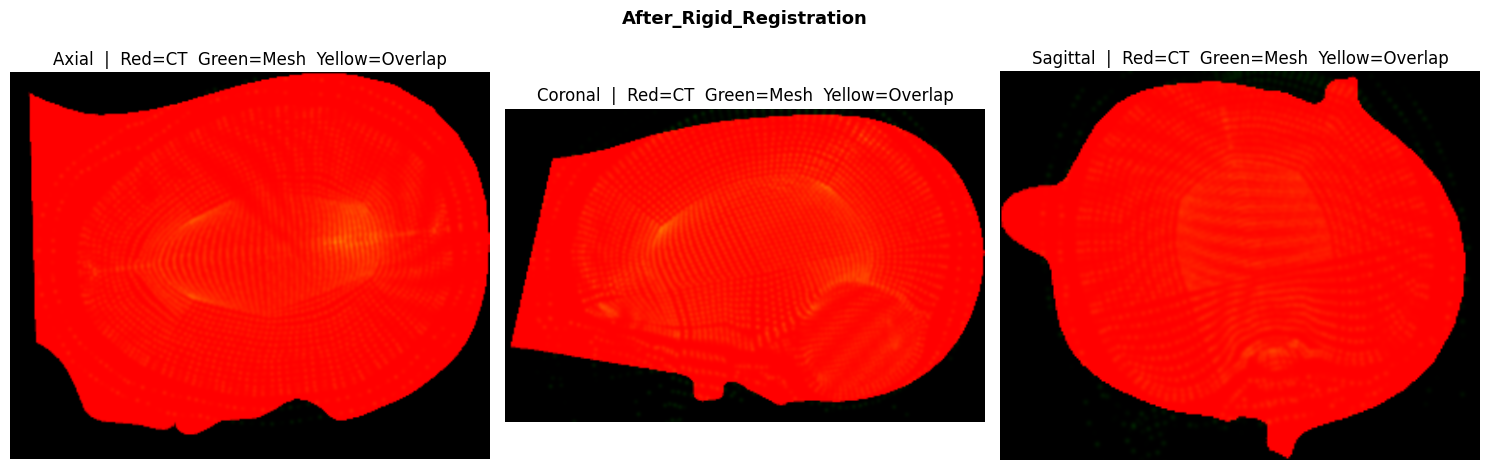

  Saved -> /run/media/asusry7/Extreme SSD/2d_3d_regis dataset/New_version/Data/outputs/case01/After_Rigid_Registration.png


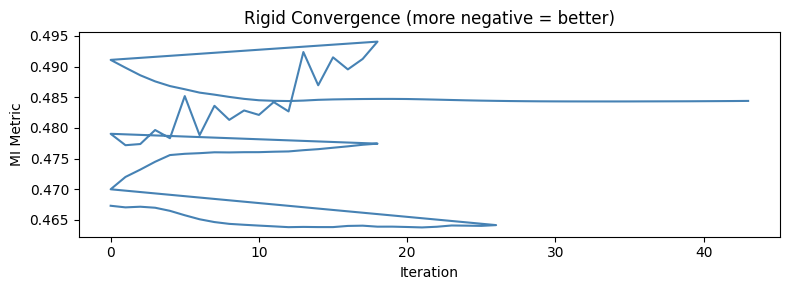

Rigid complete.


In [9]:
print('Rigid Registration (MeanSquares + large LR)...')
metric_log.clear()

reg_rigid = sitk.ImageRegistrationMethod()

# MeanSquares works far better than MI on binary/sparse voxelized meshes
# MI needs intensity variation — a voxelized point cloud has almost none
reg_rigid.SetMetricAsMeanSquares()
reg_rigid.SetMetricSamplingStrategy(reg_rigid.RANDOM)
reg_rigid.SetMetricSamplingPercentage(0.20)
reg_rigid.SetInterpolator(sitk.sitkLinear)

# Multi-resolution: coarse to fine
reg_rigid.SetShrinkFactorsPerLevel([8, 4, 2, 1])
reg_rigid.SetSmoothingSigmasPerLevel([4, 2, 1, 0])
reg_rigid.SmoothingSigmasAreSpecifiedInPhysicalUnitsOn()

# Large learning rate so the optimizer can travel far from center
# to find real overlap — the default 1.0 is too small when shapes
# are far apart after center alignment
reg_rigid.SetOptimizerAsGradientDescent(
    learningRate=10.0,
    numberOfIterations=300,
    convergenceMinimumValue=1e-7,
    convergenceWindowSize=20
)
reg_rigid.SetOptimizerScalesFromPhysicalShift()
reg_rigid.SetInitialTransform(initial_tx, inPlace=False)
reg_rigid.AddCommand(sitk.sitkIterationEvent, lambda: log_metric(reg_rigid))

rigid_tx = reg_rigid.Execute(fixed, moving)
print(f'\n  Metric : {reg_rigid.GetMetricValue():.6f}')
print(f'  Stop   : {reg_rigid.GetOptimizerStopConditionDescription()}')

resampler.SetTransform(rigid_tx)
moving_rigid = resampler.Execute(moving)
sitk.WriteImage(moving_rigid, os.path.join(OUTPUT_DIR, 'mesh_rigid.nii.gz'))

show_overlay(fixed, moving_rigid, title='After_Rigid_Registration')
plot_convergence('Rigid Convergence', color='steelblue')
print('Rigid complete.')

## Cell 7 — Affine Refinement (12-DOF)

Affine Refinement (MeanSquares)...
  Iter 0000  |  Metric: 0.481188
  Iter 0000  |  Metric: 0.486388
  Iter 0000  |  Metric: 0.489711

  Metric : 0.491036
  Stop   : GradientDescentOptimizerv4Template: Convergence checker passed at iteration 19.


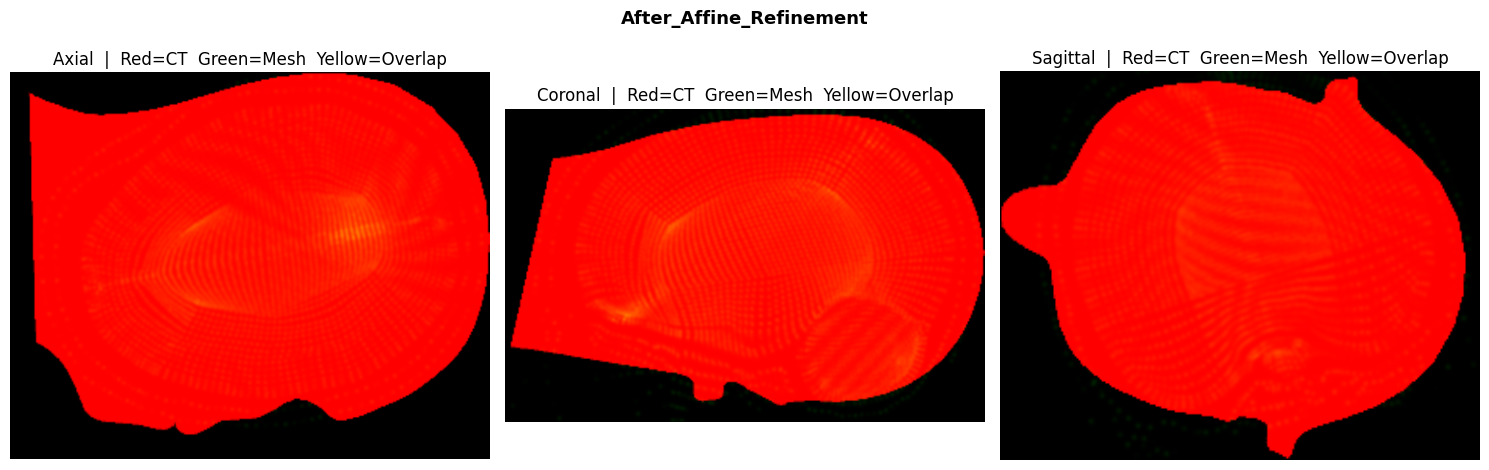

  Saved -> /run/media/asusry7/Extreme SSD/2d_3d_regis dataset/New_version/Data/outputs/case01/After_Affine_Refinement.png


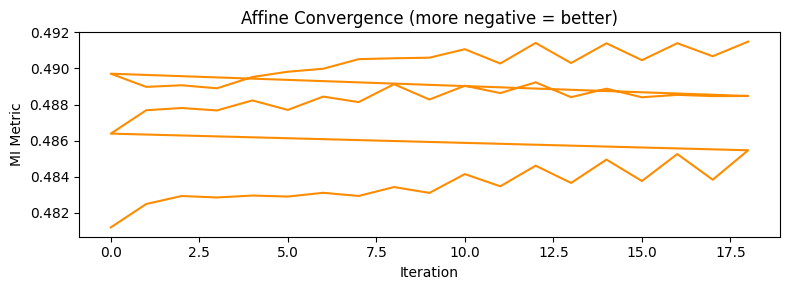

Affine complete.


In [10]:
print('Affine Refinement (MeanSquares)...')
metric_log.clear()

reg_affine = sitk.ImageRegistrationMethod()
reg_affine.SetMetricAsMeanSquares()
reg_affine.SetMetricSamplingStrategy(reg_affine.RANDOM)
reg_affine.SetMetricSamplingPercentage(0.20)
reg_affine.SetInterpolator(sitk.sitkLinear)
reg_affine.SetShrinkFactorsPerLevel([4, 2, 1])
reg_affine.SetSmoothingSigmasPerLevel([2, 1, 0])
reg_affine.SmoothingSigmasAreSpecifiedInPhysicalUnitsOn()
reg_affine.SetOptimizerAsGradientDescent(
    learningRate=5.0,
    numberOfIterations=200,
    convergenceMinimumValue=1e-7,
    convergenceWindowSize=20
)
reg_affine.SetOptimizerScalesFromPhysicalShift()
reg_affine.SetInitialTransform(rigid_tx, inPlace=False)
reg_affine.AddCommand(sitk.sitkIterationEvent, lambda: log_metric(reg_affine))

affine_tx = reg_affine.Execute(fixed, moving)
print(f'\n  Metric : {reg_affine.GetMetricValue():.6f}')
print(f'  Stop   : {reg_affine.GetOptimizerStopConditionDescription()}')

resampler.SetTransform(affine_tx)
moving_affine = resampler.Execute(moving)
sitk.WriteImage(moving_affine, os.path.join(OUTPUT_DIR, 'mesh_affine.nii.gz'))
sitk.WriteImage(fixed,         os.path.join(OUTPUT_DIR, 'ct_resampled.nii.gz'))

show_overlay(fixed, moving_affine, title='After_Affine_Refinement')
plot_convergence('Affine Convergence', color='darkorange')
print('Affine complete.')

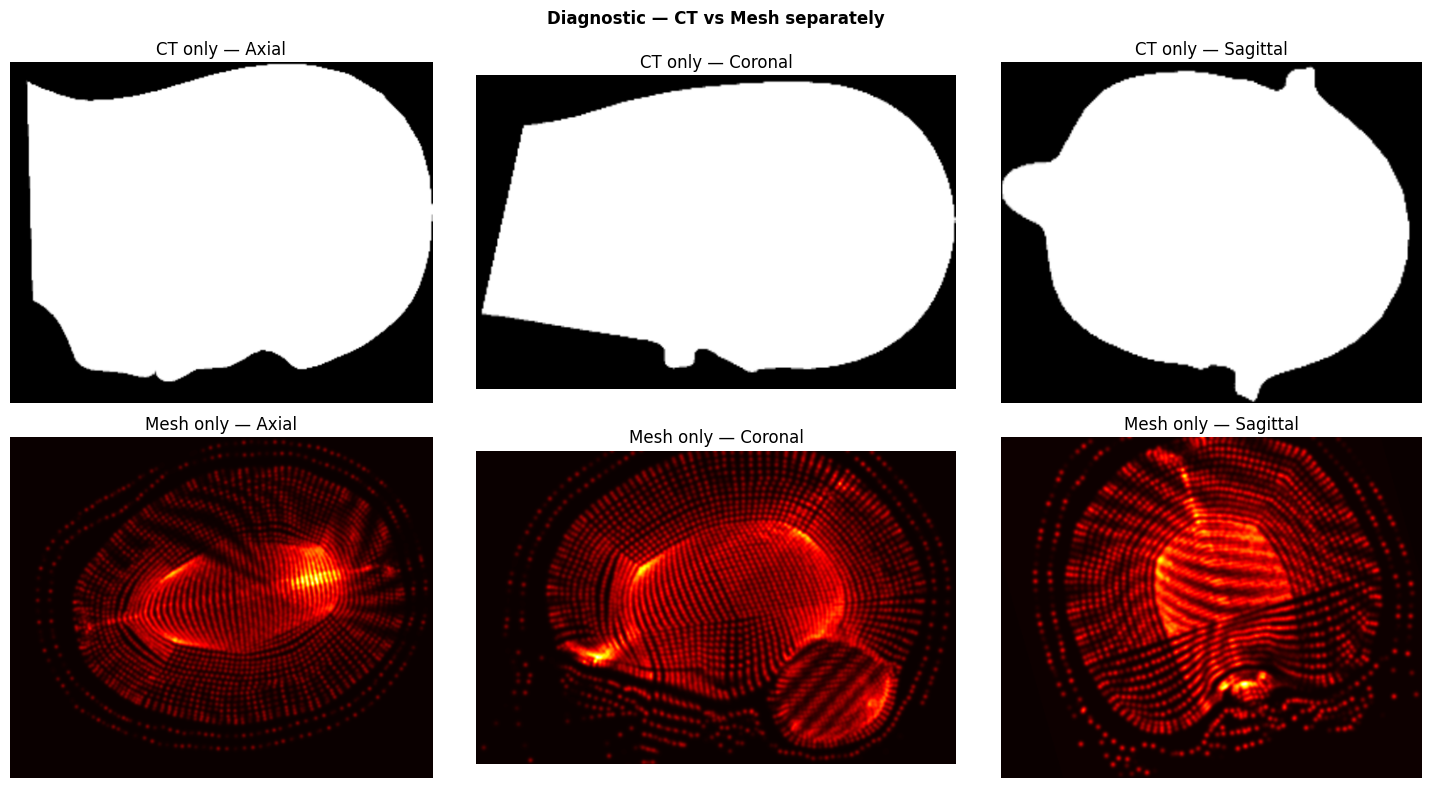


📊 Bounding box comparison (after affine):
  CT   X: [256.0, 851.0]  Y: [4.1, 484.1]  Z: [38.3, 427.3]
  Mesh X: [256.0,  851.0]   Y: [4.1,  484.1]   Z: [38.3,  427.3]

  Overlap ratio  X: 100.00%  Y: 100.00%  Z: 100.00%
  3D overlap     : 100.00%
  ✅ Good spatial overlap — shapes just differ (expected for template vs subject)


In [12]:
import matplotlib.pyplot as plt
import numpy as np
import SimpleITK as sitk

# Show each channel separately so you can see what's actually there
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Diagnostic — CT vs Mesh separately', fontsize=12, fontweight='bold')

def norm(a):
    a = a.astype(np.float32)
    return (a - a.min()) / (a.max() - a.min() + 1e-8)

ct_arr   = norm(sitk.GetArrayFromImage(fixed))
mesh_arr = norm(sitk.GetArrayFromImage(moving_affine))

z = ct_arr.shape[0] // 2
y = ct_arr.shape[1] // 2
x = ct_arr.shape[2] // 2

views_ct   = [ct_arr[z,:,:],   ct_arr[:,y,:],   ct_arr[:,:,x]]
views_mesh = [mesh_arr[z,:,:], mesh_arr[:,y,:], mesh_arr[:,:,x]]
planes     = ['Axial', 'Coronal', 'Sagittal']

# Row 1 — CT alone
for col, (sl, label) in enumerate(zip(views_ct, planes)):
    axes[0, col].imshow(sl, cmap='gray', origin='lower')
    axes[0, col].set_title(f'CT only — {label}')
    axes[0, col].axis('off')

# Row 2 — Mesh alone
for col, (sl, label) in enumerate(zip(views_mesh, planes)):
    axes[1, col].imshow(sl, cmap='hot', origin='lower')
    axes[1, col].set_title(f'Mesh only — {label}')
    axes[1, col].axis('off')

plt.tight_layout()
plt.savefig('outputs/case01/diagnostic_separate.png', dpi=130)
plt.show()

# Print bounding box overlap stats
print('\n📊 Bounding box comparison (after affine):')
ct_sp   = fixed.GetSpacing()
ct_org  = fixed.GetOrigin()
ct_sz   = fixed.GetSize()

ct_min = np.array(ct_org)
ct_max = ct_min + np.array([ct_sz[i]*ct_sp[i] for i in range(3)])

m_sp   = moving_affine.GetSpacing()
m_org  = moving_affine.GetOrigin()
m_sz   = moving_affine.GetSize()
m_min  = np.array(m_org)
m_max  = m_min + np.array([m_sz[i]*m_sp[i] for i in range(3)])

print(f'  CT   X: [{ct_min[0]:.1f}, {ct_max[0]:.1f}]  Y: [{ct_min[1]:.1f}, {ct_max[1]:.1f}]  Z: [{ct_min[2]:.1f}, {ct_max[2]:.1f}]')
print(f'  Mesh X: [{m_min[0]:.1f},  {m_max[0]:.1f}]   Y: [{m_min[1]:.1f},  {m_max[1]:.1f}]   Z: [{m_min[2]:.1f},  {m_max[2]:.1f}]')

# Overlap ratio per axis
overlap = np.maximum(0,
    np.minimum(ct_max, m_max) - np.maximum(ct_min, m_min)
)
ct_extent = ct_max - ct_min
ratio = overlap / (ct_extent + 1e-8)
print(f'\n  Overlap ratio  X: {ratio[0]:.2%}  Y: {ratio[1]:.2%}  Z: {ratio[2]:.2%}')
overall = float(np.prod(ratio))
print(f'  3D overlap     : {overall:.2%}')
if overall > 0.5:
    print('  ✅ Good spatial overlap — shapes just differ (expected for template vs subject)')
elif overall > 0.2:
    print('  ⚠️  Partial overlap — may need rotation adjustment')
else:
    print('  ❌ Poor overlap — check scale or flip axes')

## Cell 8 — Deformable Registration (Demons)
Set `RUN_DEFORMABLE = False` to use affine as final output.

In [13]:
RUN_DEFORMABLE = True

if RUN_DEFORMABLE:
    print('Deformable Registration (Demons)...')

    moving_on_fixed = sitk.Resample(
        moving_affine, fixed,
        sitk.Transform(), sitk.sitkLinear, 0.0, moving_affine.GetPixelID()
    )
    fixed_f32  = sitk.Cast(fixed,           sitk.sitkFloat32)
    moving_f32 = sitk.Cast(moving_on_fixed, sitk.sitkFloat32)

    assert fixed_f32.GetSize() == moving_f32.GetSize(), \
        f'Size mismatch: {fixed_f32.GetSize()} vs {moving_f32.GetSize()}'

    demons = sitk.DemonsRegistrationFilter()
    demons.SetNumberOfIterations(50)
    demons.SetStandardDeviations(1.5)
    disp_field = demons.Execute(fixed_f32, moving_f32)

    disp_tx       = sitk.DisplacementFieldTransform(disp_field)
    moving_deform = sitk.Resample(
        moving, fixed, disp_tx,
        sitk.sitkLinear, 0.0, moving.GetPixelID()
    )

    sitk.WriteImage(moving_deform,
                    os.path.join(OUTPUT_DIR, 'mesh_deformable_final.nii.gz'))
    sitk.WriteImage(
        sitk.Cast(disp_field, sitk.sitkVectorFloat32),
        os.path.join(OUTPUT_DIR, 'displacement_field.nii.gz')
    )

    show_overlay(fixed, moving_deform, title='After_Deformable_FINAL')
    FINAL_MOVING  = moving_deform
    FINAL_TX_TYPE = 'deformable'
    print('Deformable complete.')

else:
    FINAL_MOVING  = moving_affine
    FINAL_TX_TYPE = 'affine'
    print('Skipped -- using affine as final.')

print(f'FINAL_TX_TYPE = {FINAL_TX_TYPE}')


Deformable Registration (Demons)...


RuntimeError: Exception thrown in SimpleITK ImageFileWriter_Execute: /tmp/SimpleITK-build/ITK-prefix/include/ITK-5.4/itkImageFileWriter.hxx:245:
ITK ERROR: ImageFileWriter(0x5d2452af5f70): Largest possible region does not fully contain requested paste IO region. Paste IO region: ImageIORegion (0x7ffe3892cee0)
  Dimension: 2
  Index: 0 0 
  Size: 0 0 
Largest possible region: ImageRegion (0x7ffe3892ce40)
  Dimension: 2
  Index: [0, 0]
  Size: [0, 0]


## Cell 9 — Apply Transform to VTU Mesh -> Write New `.vtu`

Builds composite transform (initial -> rigid -> affine -> deformable),
warps every mesh point, and saves a new `.vtu`.
All original cell data, point data, and field data are preserved.
A `displacement_mm` point array is added so you can colour the mesh
by how much each node moved in ParaView.


In [ ]:
# Warp nodes_working (the scaled version used for registration)
nodes_registered_scaled = np.array(
    [composite_tx.TransformPoint(tuple(pt)) for pt in nodes_working],
    dtype=np.float64
)

# Undo the scale factor to bring back to original mesh units
# so the output .vtu is in the same coordinate space as the input
centroid_reg = nodes_registered_scaled.mean(axis=0)
nodes_registered = (nodes_registered_scaled - centroid_reg) / scale_factor + centroid_reg

displacements = np.linalg.norm(nodes_registered - nodes_original, axis=1)
print(f'  Mean displacement : {displacements.mean():.3f}')
print(f'  Max  displacement : {displacements.max():.3f}')

registered_mesh = vtu_mesh.copy(deep=True)
registered_mesh.points = nodes_registered
registered_mesh.point_data['displacement_mm'] = displacements.astype(np.float32)

out_vtu_path = os.path.join(OUTPUT_DIR, f'{stem}_registered.vtu')
registered_mesh.save(out_vtu_path, binary=True)
print(f'Saved -> {out_vtu_path}')

## Cell 10 — Validation

In [ ]:
# Mutual Information
print('Mutual Information Score:')
try:
    def norm_mi(a):
        vmin, vmax = a.min(), a.max()
        return (a - vmin) / (vmax - vmin + 1e-8)

    f_norm = norm_mi(sitk.GetArrayFromImage(fixed).astype(np.float32)).ravel()
    m_norm = norm_mi(sitk.GetArrayFromImage(FINAL_MOVING).astype(np.float32)).ravel()

    joint_hist, _, _ = np.histogram2d(f_norm, m_norm, bins=64, range=[[0,1],[0,1]])
    joint_hist = joint_hist / joint_hist.sum()
    p_f = joint_hist.sum(axis=1)
    p_m = joint_hist.sum(axis=0)
    outer   = np.outer(p_f, p_m)
    nonzero = joint_hist > 0
    mi  = float(np.sum(joint_hist[nonzero] * np.log(joint_hist[nonzero] / (outer[nonzero] + 1e-12))))
    h_f = -np.sum(p_f[p_f>0] * np.log(p_f[p_f>0]))
    h_m = -np.sum(p_m[p_m>0] * np.log(p_m[p_m>0]))
    nmi = mi / (np.sqrt(h_f * h_m) + 1e-12)

    print(f'  MI  (raw) : {mi:.4f} nats')
    print(f'  NMI       : {nmi:.4f}  [0=no overlap, 1=perfect]')
    if nmi >= 0.7:   print('  PASS -- strong MI')
    elif nmi >= 0.4: print('  MARGINAL')
    else:            print('  FAIL -- check alignment')
except Exception as e:
    print(f'  Could not compute MI: {e}')


# Alpha blend + checkerboard
def norm_display(a):
    a = a.astype(np.float32)
    return (a - a.min()) / (a.max() - a.min() + 1e-8)

ct_arr  = norm_display(sitk.GetArrayFromImage(fixed))
mri_arr = norm_display(sitk.GetArrayFromImage(FINAL_MOVING))
z, y, x = ct_arr.shape[0]//2, ct_arr.shape[1]//2, ct_arr.shape[2]//2

ct_sl  = [ct_arr[z,:,:],  ct_arr[:,y,:],  ct_arr[:,:,x]]
mri_sl = [mri_arr[z,:,:], mri_arr[:,y,:], mri_arr[:,:,x]]
planes = ['Axial', 'Coronal', 'Sagittal']

fig = plt.figure(figsize=(18, 10))
fig.suptitle('Validation -- CT (Red) vs Registered Mesh (Green)', fontsize=13, fontweight='bold')
gs = gridspec.GridSpec(2, 3, figure=fig)

for col, (cs, ms, label) in enumerate(zip(ct_sl, mri_sl, planes)):
    ax = fig.add_subplot(gs[0, col])
    rgb = np.zeros((*cs.shape, 3), dtype=np.float32)
    rgb[...,0] = cs; rgb[...,1] = ms
    ax.imshow(rgb, origin='lower')
    ax.set_title(f'Alpha Blend -- {label}')
    ax.axis('off')

for col, (cs, ms, label) in enumerate(zip(ct_sl, mri_sl, planes)):
    ax = fig.add_subplot(gs[1, col])
    ax.imshow(checkerboard(cs, ms, block=20), cmap='gray', origin='lower')
    ax.set_title(f'Checkerboard -- {label}')
    ax.axis('off')

plt.tight_layout()
val_path = os.path.join(OUTPUT_DIR, 'validation_result.png')
plt.savefig(val_path, dpi=130)
plt.show()
print(f'Validation image -> {val_path}')


# Dice score
print('\nDice Score:')
try:
    ct_bin  = sitk.Cast(sitk.BinaryThreshold(fixed,        0.1, 1.0, 1, 0), sitk.sitkUInt8)
    mri_bin = sitk.Cast(sitk.BinaryThreshold(FINAL_MOVING, 0.1, 1.0, 1, 0), sitk.sitkUInt8)
    overlap = sitk.LabelOverlapMeasuresImageFilter()
    overlap.Execute(ct_bin, mri_bin)
    dice = overlap.GetDiceCoefficient()
    print(f'  Dice: {dice:.4f}')
    if dice >= 0.85:   print('  PASS (>= 0.85)')
    elif dice >= 0.70: print('  MARGINAL (0.70-0.85)')
    else:              print('  FAIL (< 0.70)')
except Exception as e:
    print(f'  {e}')


# Displacement histogram
plt.figure(figsize=(8, 3))
plt.hist(displacements, bins=60, color='steelblue', edgecolor='white', linewidth=0.3)
plt.xlabel('Displacement (mm)')
plt.ylabel('Node count')
plt.title('Node displacement magnitude -- original vs registered')
plt.tight_layout()
disp_path = os.path.join(OUTPUT_DIR, 'displacement_histogram.png')
plt.savefig(disp_path, dpi=120)
plt.show()
print(f'Histogram -> {disp_path}')


# File summary
print('\n' + '='*60)
print('OUTPUT FILES:')
for fname in sorted(os.listdir(OUTPUT_DIR)):
    fpath = os.path.join(OUTPUT_DIR, fname)
    fsize = os.path.getsize(fpath) / 1e6
    print(f'  {fname:<50} {fsize:.1f} MB')
print('='*60)
print(f'\nKEY OUTPUT: {stem}_registered.vtu')
print('  -> Open in ParaView or 3D Slicer')
print('  -> Colour by displacement_mm to visualize warp magnitude')
